## imports and data loading

In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.preprocessing import LabelEncoder
import pickle

df = pd.read_csv("../cleaned_dataset.csv")
print(f"Dataset loaded: {df.shape[0]} rows × {df.shape[1]} columns")
df.head()

Dataset loaded: 11896 rows × 28 columns


,Date,Service,Gare de départ,Gare d'arrivée,Durée moyenne du trajet,Nombre de circulations prévues,Nombre de trains annulés,Commentaire annulations,Nombre de trains en retard au départ,Retard moyen des trains en retard au départ,...,Nombre trains en retard > 30min,Nombre trains en retard > 60min,Prct retard pour causes externes,Prct retard pour cause infrastructure,Prct retard pour cause gestion trafic,Prct retard pour cause matériel roulant,Prct retard pour cause gestion en gare et réutilisation de matériel,"Prct retard pour cause prise en compte voyageurs (affluence, gestions PSH, correspondances)",Year,Month
0,2018-01-01,National,BORDEAUX ST JEAN,PARIS MONTPARNASSE,141.00,870.0,5.0,NaN,289.0,11.247809,...,44.0,8.0,36.134454,31.092437,10.924370,15.966387,NaN,0.840336,2018.0,1.0
1,2018-01-01,National,LE MANS,PARIS MONTPARNASSE,56.00,406.0,1.0,NaN,213.0,8.479969,...,9.0,4.0,20.000000,35.000000,16.666667,16.666667,8.333333,3.333333,2018.0,1.0
2,2018-01-01,National,PARIS MONTPARNASSE,LA ROCHELLE VILLE,166.00,226.0,0.0,NaN,21.0,6.239683,...,6.0,1.0,22.222222,27.777778,16.666667,16.666667,5.555556,11.111111,2018.0,1.0
3,2018-01-01,National,PARIS MONTPARNASSE,NANTES,216.21,508.0,3.0,NaN,71.0,7.235211,...,18.0,NaN,33.333333,22.222222,16.666667,20.370370,5.555556,1.851852,2018.0,1.0
4,2018-01-01,National,POITIERS,PARIS MONTPARNASSE,94.00,472.0,4.0,NaN,224.0,6.784673,...,10.0,0.0,15.789474,45.614035,NaN,15.789474,1.754386,1.754386,2018.0,1.0


## Preparation of Features 

In [18]:
# the prediction needed
target = "Retard moyen de tous les trains à l'arrivée"

# inputs the model will use
features = [
    "Gare de départ",
    "Gare d'arrivée",
    "Service",
    "Month",
    "Year",
    "Nombre de circulations prévues",
    "Nombre de trains annulés",
]

print(f"Target  : {target}")
print(f"Features: {features}")

# date features
df["Date"] = pd.to_datetime(df["Date"], errors="coerce")
df["Year"] = df["Date"].dt.year
df["Month"] = df["Date"].dt.month

# droping the  missing values
df_model = df[features + [target]].dropna()
print(f"Rows after dropping missing values: {df_model.shape[0]}")

# encode categorical columns into numbers
le = LabelEncoder()
for col in ["Gare de départ", "Gare d'arrivée", "Service"]:
    df_model[col] = le.fit_transform(df_model[col].astype(str))

print("Feature preparation done")
df_model.head()

Target  : Retard moyen de tous les trains à l'arrivée
Features: ['Gare de départ', "Gare d'arrivée", 'Service', 'Month', 'Year', 'Nombre de circulations prévues', 'Nombre de trains annulés']
Rows after dropping missing values: 10363
Feature preparation done


,Gare de départ,Gare d'arrivée,Service,Month,Year,Nombre de circulations prévues,Nombre de trains annulés,Retard moyen de tous les trains à l'arrivée
0,35,68,1,1.0,2018.0,870.0,5.0,6.511118
1,52,68,1,1.0,2018.0,406.0,1.0,5.363539
2,78,43,1,1.0,2018.0,226.0,0.0,2.938053
3,78,62,1,1.0,2018.0,508.0,3.0,5.292211
4,82,68,1,1.0,2018.0,472.0,4.0,4.882372


## split data

In [10]:
X = df_model[features]
y = df_model[target]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"Training samples : {X_train.shape[0]}")
print(f"Testing samples  : {X_test.shape[0]}")

Training samples : 8290
Testing samples  : 2073


## baseline

In [11]:
# predicting the average delay
baseline_pred = np.full(len(y_test), y_train.mean())

print("Baseline — always predict mean delay:")
print(f"  Mean delay used : {y_train.mean():.2f} minutes")
print(f"  RMSE : {np.sqrt(mean_squared_error(y_test, baseline_pred)):.4f}")
print(f"  MAE  : {mean_absolute_error(y_test, baseline_pred):.4f}")
print(f"  R²   : {r2_score(y_test, baseline_pred):.4f}")

Baseline — always predict mean delay:
  Mean delay used : 6.08 minutes
  RMSE : 6.2334
  MAE  : 3.2567
  R²   : -0.0000


## train models

In [12]:
# Model 1 — Linear Regression (this runs fast)
lr = LinearRegression()
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)
print("Linear Regression trained")

# Model 2 — Random Forest (it runs slower but more efficient )
rf = RandomForestRegressor(n_estimators=10, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)
print("Random Forest trained")

Linear Regression trained
Random Forest trained


## evaluate

In [13]:
def evaluate(name, y_true, y_pred):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    print(f"\n{name}:")
    print(f"  RMSE : {rmse:.4f} minutes")
    print(f"  MAE  : {mae:.4f} minutes")
    print(f"  R²   : {r2:.4f}")
    return rmse, mae, r2


evaluate("Linear Regression", y_test, y_pred_lr)
evaluate("Random Forest", y_test, y_pred_rf)


Linear Regression:
  RMSE : 6.1695 minutes
  MAE  : 3.1595 minutes
  R²   : 0.0204

Random Forest:
  RMSE : 5.5315 minutes
  MAE  : 2.4035 minutes
  R²   : 0.2125


(np.float64(5.531478247912048), 2.4035314872524713, 0.21250706851427603)

## plot results

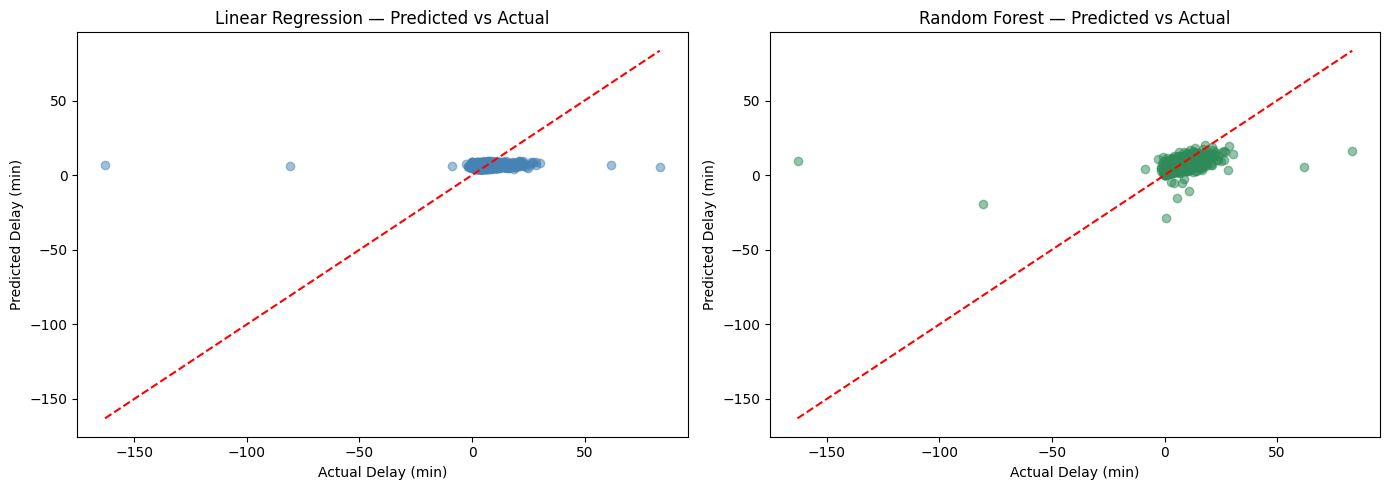

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Linear Regression plot
axes[0].scatter(y_test, y_pred_lr, alpha=0.5, color="steelblue")
axes[0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], "r--")
axes[0].set_title("Linear Regression — Predicted vs Actual")
axes[0].set_xlabel("Actual Delay (min)")
axes[0].set_ylabel("Predicted Delay (min)")

# Random Forest plot
axes[1].scatter(y_test, y_pred_rf, alpha=0.5, color="seagreen")
axes[1].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], "r--")
axes[1].set_title("Random Forest — Predicted vs Actual")
axes[1].set_xlabel("Actual Delay (min)")
axes[1].set_ylabel("Predicted Delay (min)")

plt.tight_layout()
plt.show()

## best model

In [15]:
Path("../models").mkdir(exist_ok=True)

with open("../models/model.pkl", "wb") as f:
    pickle.dump(rf, f)

print("Model saved to models/model.pkl")

Model saved to models/model.pkl
